        Date     Product     Category  Price  Quantity       City   Sales
0 2024-01-01       Mouse  Electronics  15845         8       Pune  126760
1 2024-01-02  Headphones  Electronics  54936         3     Jaipur  164808
2 2024-01-03        Rice      Grocery  47241         5  Bangalore  236205
3 2024-01-04       Shoes      Fashion  16073         3       Pune   48219
4 2024-01-05       Phone  Electronics  59785         6     Mumbai  358710
\nShape: (250, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      250 non-null    datetime64[ns]
 1   Product   250 non-null    object        
 2   Category  250 non-null    object        
 3   Price     250 non-null    int64         
 4   Quantity  250 non-null    int64         
 5   City      250 non-null    object        
 6   Sales     250 non-null    int64         
dtypes: datetime64[n

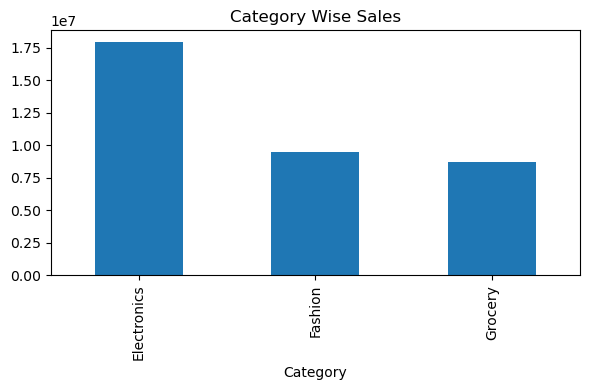

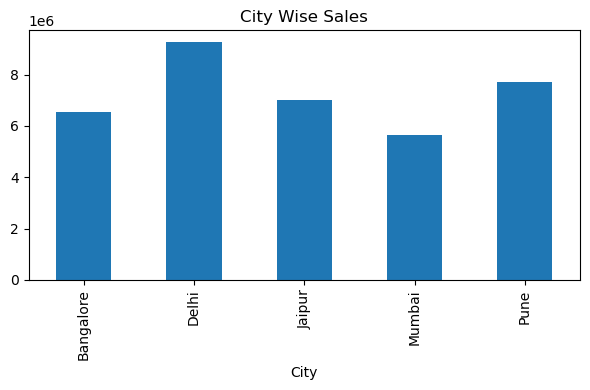

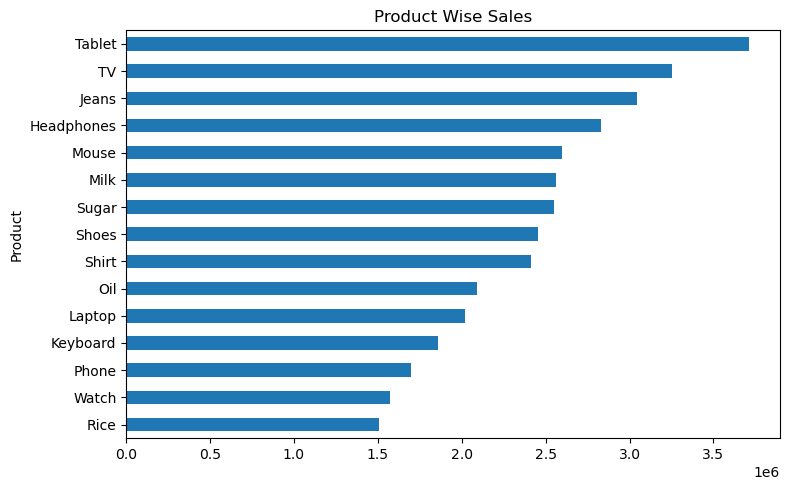

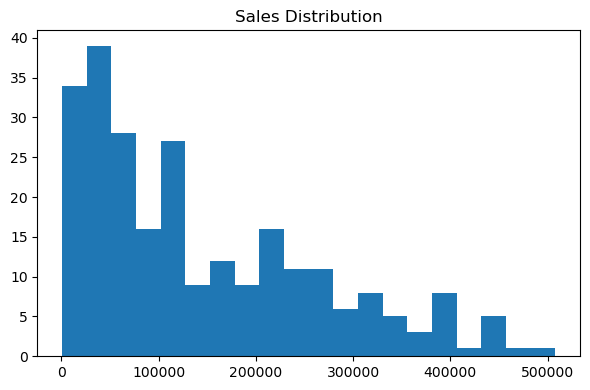

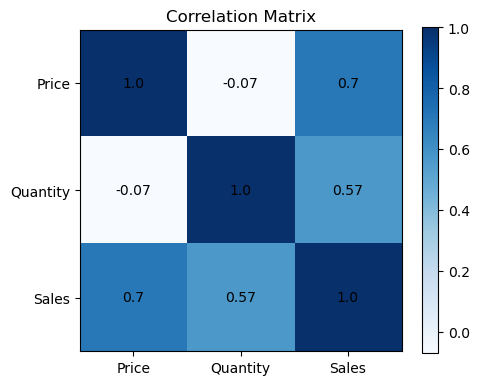

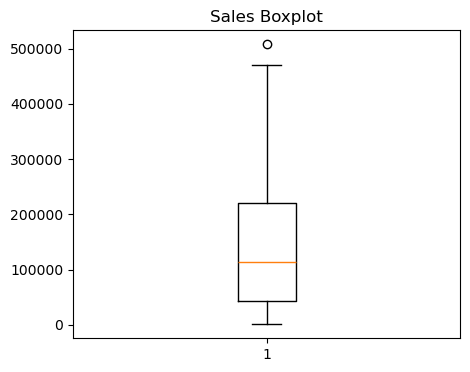

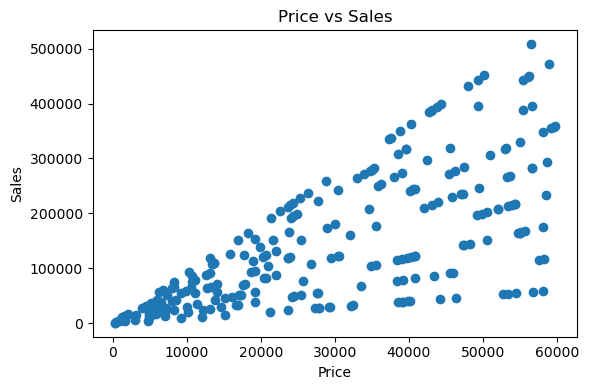

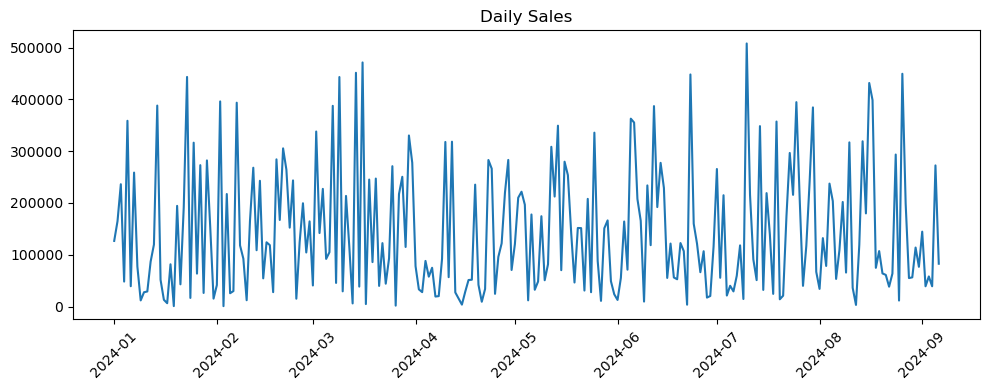

\nModel Performance
MAE : 36471.86589863491
MSE : 2148344691.0058765
RMSE : 46350.23938455849
R2 Score : 0.8234137958501772
    Actual  Predicted
0    30870   74438.12
1   258687  264981.20
2    19320  -19157.33
3    40663   76821.56
4    33892  -11040.10
5   116382  199513.08
6   219015  243070.90
7   214947  234073.45
8    27580   72718.17
9    15505    6394.46
10  357264  329303.85
11  237411  244727.26
12  293530  293126.05
13   54966   63318.68
14   45603    4821.63
15    3162 -100611.40
16   51023   82279.77
17   13080   87136.00
18   66330   57502.68
19  316432  284138.02


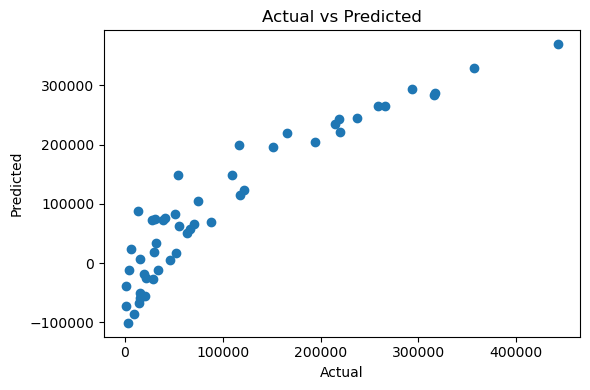

\nBusiness Conclusions
1. Electronics contributes high revenue.
2. Sales increase with quantity.
3. Price strongly influences sales.
4. Model predicts sales with good accuracy.
5. This project demonstrates an end-to-end retail analytics workflow.


In [1]:

# ==========================
# IMPORT LIBRARIES
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================
# CREATE DATASET
# ==========================
np.random.seed(42)

products = ["Laptop","Phone","Tablet","TV","Headphones","Keyboard","Mouse",
            "Shoes","Shirt","Jeans","Rice","Milk","Oil","Sugar","Watch"]

categories = {
    "Laptop":"Electronics","Phone":"Electronics","Tablet":"Electronics",
    "TV":"Electronics","Headphones":"Electronics","Keyboard":"Electronics",
    "Mouse":"Electronics","Shoes":"Fashion","Shirt":"Fashion",
    "Jeans":"Fashion","Watch":"Fashion","Rice":"Grocery",
    "Milk":"Grocery","Oil":"Grocery","Sugar":"Grocery"
}

cities=["Delhi","Mumbai","Jaipur","Bangalore","Pune"]

rows=[]
dates=pd.date_range("2024-01-01",periods=250)

for d in dates:
    p=np.random.choice(products)
    c=categories[p]
    price=np.random.randint(50,60000)
    qty=np.random.randint(1,10)
    city=np.random.choice(cities)
    rows.append([d,p,c,price,qty,city])

df=pd.DataFrame(rows,columns=["Date","Product","Category","Price","Quantity","City"])
df["Sales"]=df["Price"]*df["Quantity"]

print(df.head())

print("\\nShape:",df.shape)
print(df.info())
print(df.describe())

print("\\nMissing Values")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

# ==========================
# EDA
# ==========================
print("\\nTotal Sales:",df["Sales"].sum())
print("Average Sales:",df["Sales"].mean())

print("\\nCategory Sales")
print(df.groupby("Category")["Sales"].sum())

print("\\nCity Sales")
print(df.groupby("City")["Sales"].sum())

print("\\nTop Products")
print(df.groupby("Product")["Sales"].sum().sort_values(ascending=False))

# ==========================
# VISUALIZATIONS
# ==========================

plt.figure(figsize=(6,4))
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Category Wise Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
df.groupby("City")["Sales"].sum().plot(kind="bar")
plt.title("City Wise Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
df.groupby("Product")["Sales"].sum().sort_values().plot(kind="barh")
plt.title("Product Wise Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["Sales"],bins=20)
plt.title("Sales Distribution")
plt.tight_layout()
plt.show()

corr=df[["Price","Quantity","Sales"]].corr()
plt.figure(figsize=(5,4))
plt.imshow(corr,cmap="Blues")
plt.xticks(range(len(corr.columns)),corr.columns)
plt.yticks(range(len(corr.columns)),corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j,i,round(corr.iloc[i,j],2),ha="center",va="center")
plt.title("Correlation Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.boxplot(df["Sales"])
plt.title("Sales Boxplot")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["Price"],df["Sales"])
plt.xlabel("Price")
plt.ylabel("Sales")
plt.title("Price vs Sales")
plt.tight_layout()
plt.show()

daily=df.groupby("Date")["Sales"].sum()
plt.figure(figsize=(10,4))
plt.plot(daily.index,daily.values)
plt.xticks(rotation=45)
plt.title("Daily Sales")
plt.tight_layout()
plt.show()

# ==========================
# MACHINE LEARNING
# ==========================

enc1=LabelEncoder()
enc2=LabelEncoder()
enc3=LabelEncoder()

df["Product"]=enc1.fit_transform(df["Product"])
df["Category"]=enc2.fit_transform(df["Category"])
df["City"]=enc3.fit_transform(df["City"])

X=df[["Product","Category","Price","Quantity","City"]]
y=df["Sales"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

pred=model.predict(X_test)

print("\\nModel Performance")
print("MAE :",mean_absolute_error(y_test,pred))
print("MSE :",mean_squared_error(y_test,pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))
print("R2 Score :",r2_score(y_test,pred))

result=pd.DataFrame({"Actual":y_test.values,
                     "Predicted":pred.round(2)})

print(result.head(20))

plt.figure(figsize=(6,4))
plt.scatter(y_test,pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

print("\\nBusiness Conclusions")
print("1. Electronics contributes high revenue.")
print("2. Sales increase with quantity.")
print("3. Price strongly influences sales.")
print("4. Model predicts sales with good accuracy.")
print("5. This project demonstrates an end-to-end retail analytics workflow.")


Dataset Created Successfully

First 10 Rows
         Date     Product     Category  Price  Quantity    City   Sales
0  2024-04-12          TV  Electronics  33328         3  Jaipur   99984
1  2024-03-28  Headphones  Electronics   2619         4  Jaipur   10476
2  2024-05-29  Headphones  Electronics   2282         5   Delhi   11410
3  2024-11-09    Keyboard  Electronics   1658         9   Delhi   14922
4  2024-02-28       Sugar      Grocery     46         3    Pune     138
5  2024-02-24          TV  Electronics  35545         9  Jaipur  319905
6  2024-11-02       Mouse  Electronics    636         5  Mumbai    3180
7  2024-12-05        Rice      Grocery   1027         7    Pune    7189
8  2024-09-20       Sugar      Grocery     47         2    Pune      94
9  2024-01-02         Oil      Grocery    148         6  Mumbai     888

Shape of Dataset
(1000, 7)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Colum

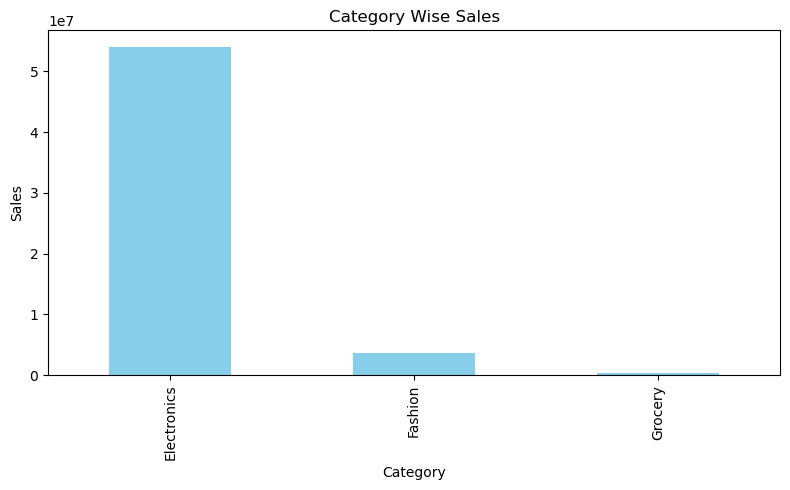

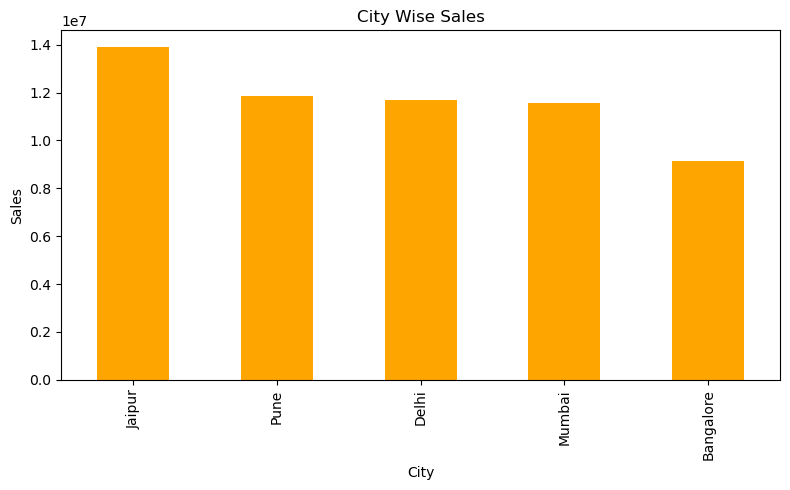

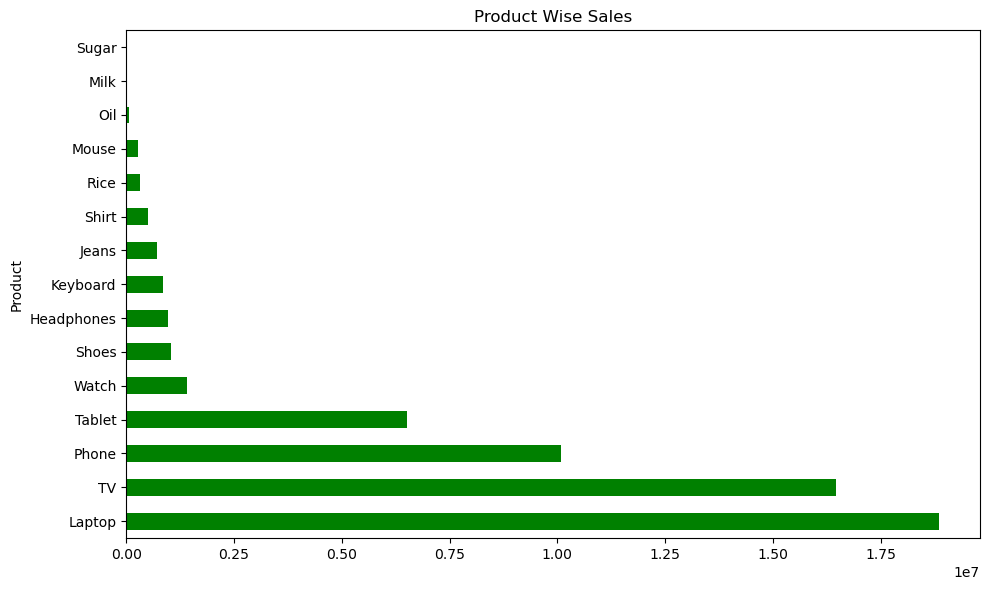

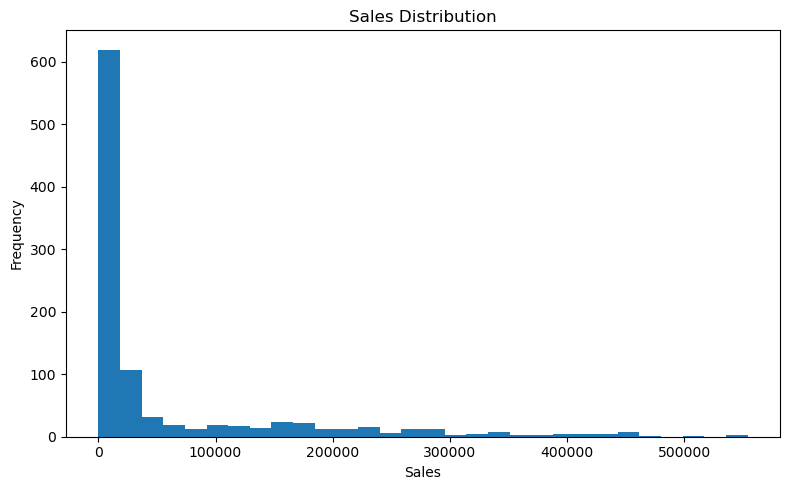

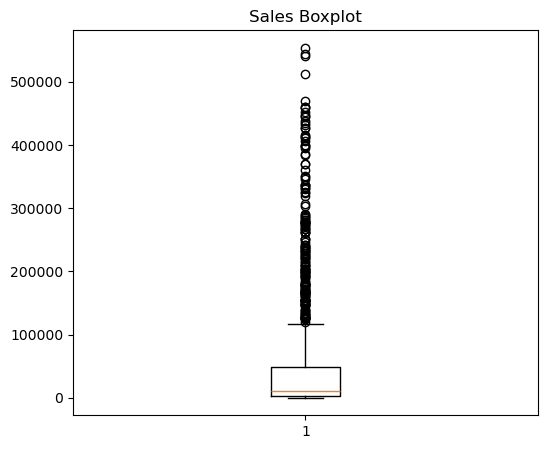

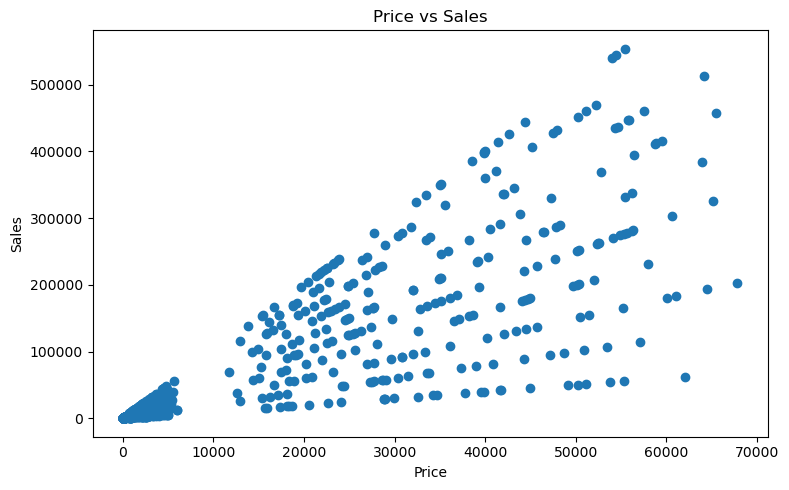

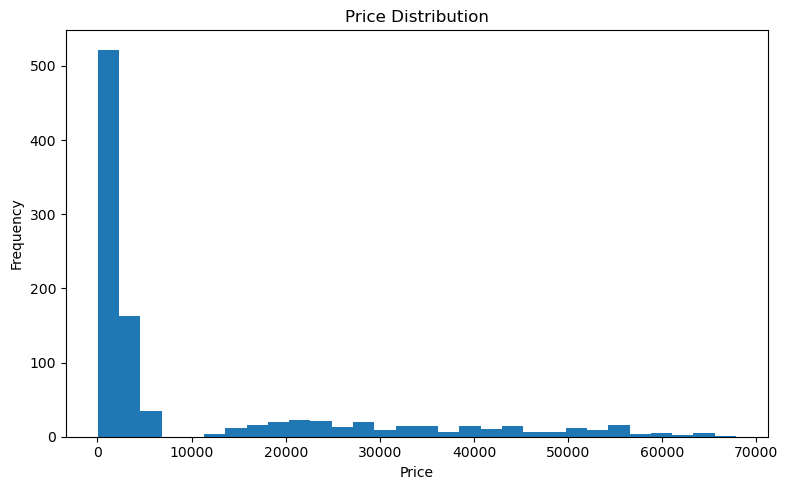

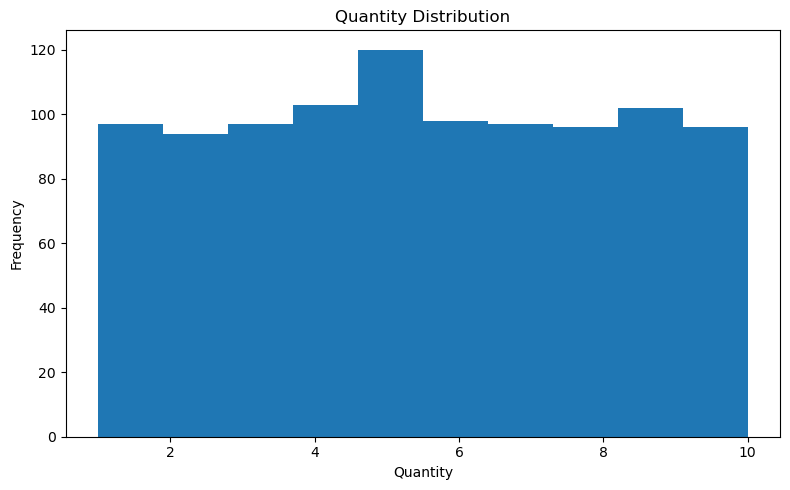

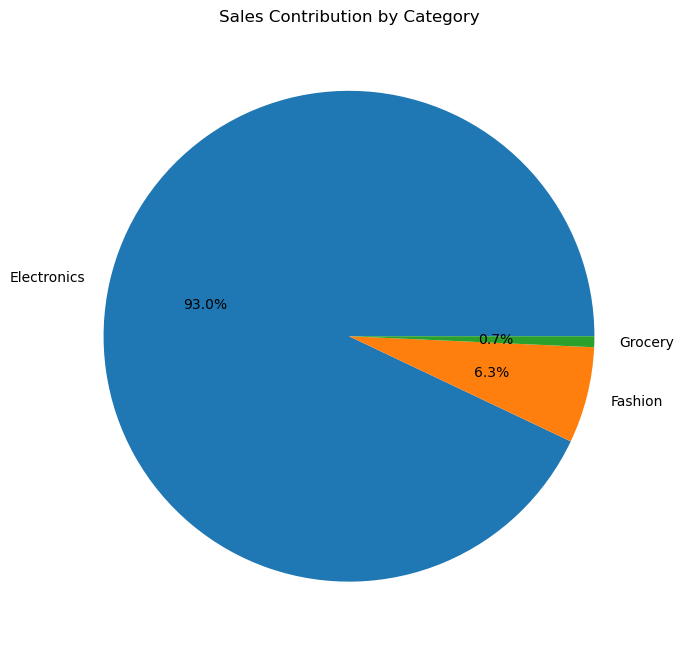

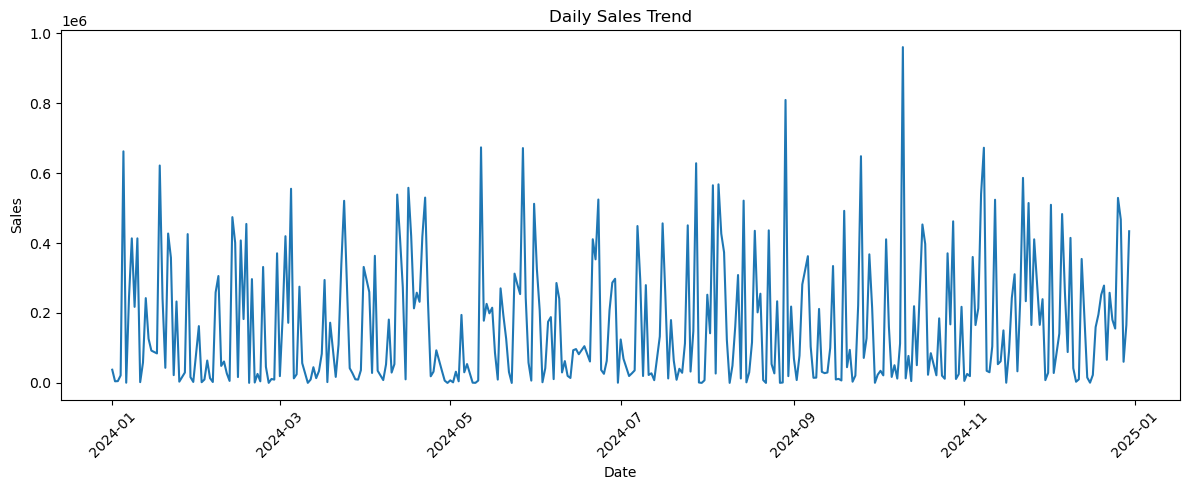

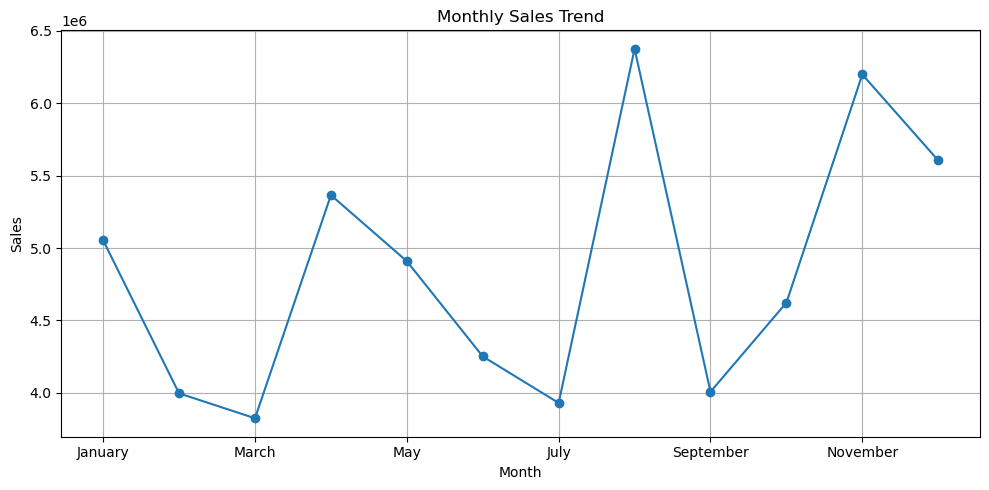

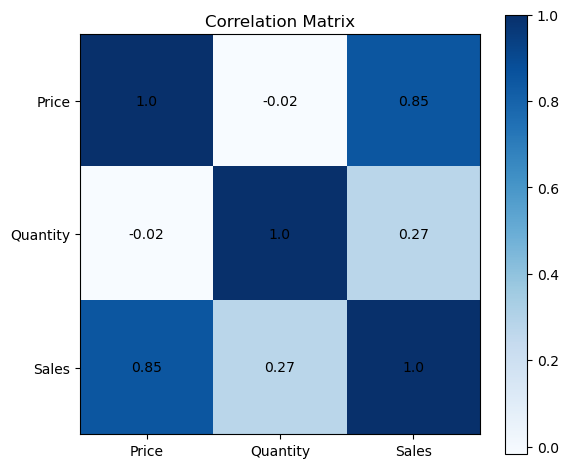


EDA COMPLETED SUCCESSFULLY
✓ Statistical Summary
✓ Category Wise Analysis
✓ City Wise Analysis
✓ Product Wise Analysis
✓ Monthly Sales Analysis
✓ Daily Sales Trend
✓ Correlation Analysis
✓ 12 Professional Graphs Generated

MACHINE LEARNING
Training Data : (800, 5)
Testing Data  : (200, 5)

Linear Regression
MAE : 33519.53
MSE : 2064049123.63
RMSE: 45431.81
R2 Score : 0.7863

Decision Tree
MAE : 3947.98
MSE : 104646376.89
RMSE: 10229.68
R2 Score : 0.9892

Random Forest
MAE : 2478.79
MSE : 58990239.96
RMSE: 7680.51
R2 Score : 0.9939


MODEL COMPARISON
               Model           MAE           MSE          RMSE  R2 Score
0  Linear Regression  33519.527887  2.064049e+09  45431.807400  0.786280
1      Decision Tree   3947.980000  1.046464e+08  10229.681172  0.989164
2      Random Forest   2478.793550  5.899024e+07   7680.510397  0.993892

Best Performing Model
           Model         MAE           MSE         RMSE  R2 Score
2  Random Forest  2478.79355  5.899024e+07  7680.510397  0.993

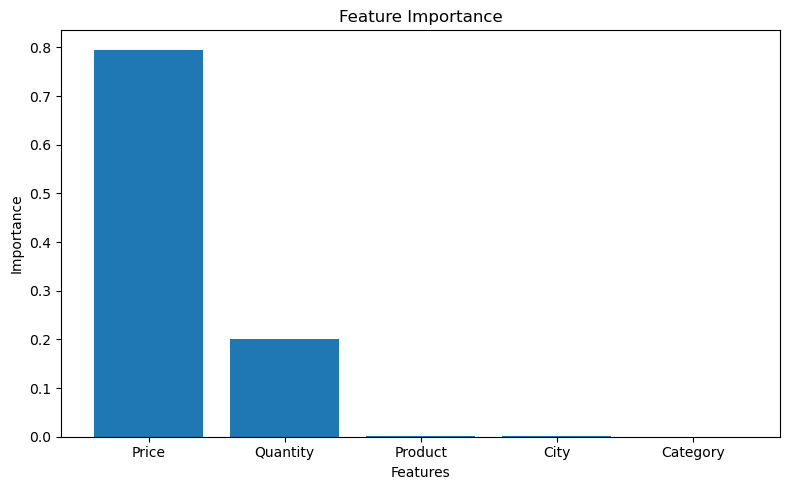

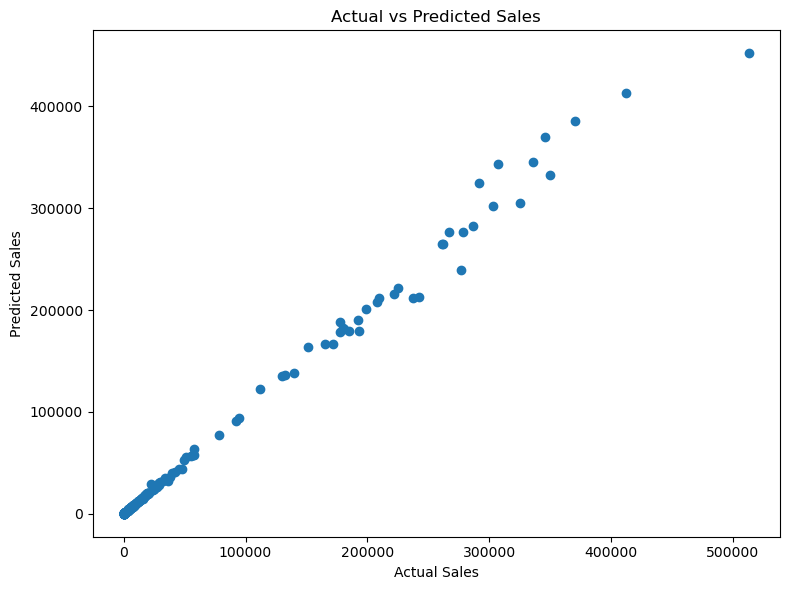


BUSINESS INSIGHTS
1. Electronics category contributes the highest revenue.
2. Higher product price generally results in higher sales.
3. Increasing quantity sold directly increases total sales.
4. Focus marketing on top-performing cities.
5. Random Forest provides the highest prediction accuracy.
6. Stock management should prioritize top-selling products.
7. Sales trends can help in inventory planning.

PROJECT CONCLUSION

This project successfully demonstrates an end-to-end
Retail Sales Analysis using Python.

Project Highlights:
✔ Dataset Generation
✔ Data Cleaning
✔ Exploratory Data Analysis
✔ Statistical Summary
✔ 12+ Visualizations
✔ Correlation Analysis
✔ Feature Engineering
✔ Machine Learning
✔ Model Comparison
✔ Sales Prediction
✔ Business Insights
✔ Final Conclusion

The Random Forest model achieved the best performance,
making it suitable for future retail sales prediction.



In [2]:
# ============================================================
# REAL-WORLD RETAIL SALES ANALYSIS & PREDICTION PROJECT
# Part 1: Import Libraries, Generate Dataset & Data Cleaning
# ============================================================

# -----------------------------
# Import Required Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# Set Random Seed
# -----------------------------
np.random.seed(42)

# -----------------------------
# Product Information
# -----------------------------
products = {
    "Laptop": ("Electronics", 55000),
    "Phone": ("Electronics", 25000),
    "Tablet": ("Electronics", 18000),
    "TV": ("Electronics", 40000),
    "Headphones": ("Electronics", 2500),
    "Keyboard": ("Electronics", 1800),
    "Mouse": ("Electronics", 700),
    "Shoes": ("Fashion", 3000),
    "Shirt": ("Fashion", 1500),
    "Jeans": ("Fashion", 2500),
    "Watch": ("Fashion", 4500),
    "Rice": ("Grocery", 900),
    "Milk": ("Grocery", 60),
    "Oil": ("Grocery", 180),
    "Sugar": ("Grocery", 50)
}

# -----------------------------
# Cities
# -----------------------------
cities = [
    "Delhi",
    "Mumbai",
    "Jaipur",
    "Pune",
    "Bangalore"
]

# -----------------------------
# Generate Dataset
# -----------------------------
rows = []

dates = pd.date_range(
    start="2024-01-01",
    periods=365,
    freq="D"
)

for i in range(1000):

    date = np.random.choice(dates)

    product = np.random.choice(list(products.keys()))

    category = products[product][0]

    base_price = products[product][1]

    price = int(np.random.normal(base_price, base_price * 0.15))

    if price < 10:
        price = 10

    quantity = np.random.randint(1, 11)

    city = np.random.choice(cities)

    sales = price * quantity

    rows.append([
        date,
        product,
        category,
        price,
        quantity,
        city,
        sales
    ])

# -----------------------------
# Create DataFrame
# -----------------------------
df = pd.DataFrame(
    rows,
    columns=[
        "Date",
        "Product",
        "Category",
        "Price",
        "Quantity",
        "City",
        "Sales"
    ]
)

# -----------------------------
# Save Dataset
# -----------------------------
df.to_csv("retail_sales_dataset.csv", index=False)

print("Dataset Created Successfully")
print()

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("retail_sales_dataset.csv")

print("First 10 Rows")
print(df.head(10))

print()

# -----------------------------
# Dataset Shape
# -----------------------------
print("Shape of Dataset")
print(df.shape)

print()

# -----------------------------
# Dataset Information
# -----------------------------
print("Dataset Information")
print(df.info())

print()

# -----------------------------
# Statistical Summary
# -----------------------------
print("Statistical Summary")
print(df.describe())

print()

# -----------------------------
# Check Missing Values
# -----------------------------
print("Missing Values")
print(df.isnull().sum())

print()

# -----------------------------
# Remove Duplicate Records
# -----------------------------
df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates")
print(df.shape)

print()

# -----------------------------
# Convert Date Column
# -----------------------------
df["Date"] = pd.to_datetime(df["Date"])

# -----------------------------
# Create New Columns
# -----------------------------
df["Month"] = df["Date"].dt.month_name()

df["Year"] = df["Date"].dt.year

df["Day"] = df["Date"].dt.day_name()

print("Dataset Ready for Analysis")

print(df.head())
# ============================================================
# PART 2 : EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# ------------------------------------------------
# Total Sales
# ------------------------------------------------
total_sales = df["Sales"].sum()

print("\nTotal Sales : ₹{:,.2f}".format(total_sales))

# ------------------------------------------------
# Average Sales
# ------------------------------------------------
average_sales = df["Sales"].mean()

print("Average Sales : ₹{:,.2f}".format(average_sales))

# ------------------------------------------------
# Highest Sale
# ------------------------------------------------
print("Highest Sale : ₹{:,.2f}".format(df["Sales"].max()))

# ------------------------------------------------
# Lowest Sale
# ------------------------------------------------
print("Lowest Sale : ₹{:,.2f}".format(df["Sales"].min()))

# ------------------------------------------------
# Average Price
# ------------------------------------------------
print("Average Product Price : ₹{:,.2f}".format(df["Price"].mean()))

# ------------------------------------------------
# Average Quantity
# ------------------------------------------------
print("Average Quantity Sold :", round(df["Quantity"].mean(),2))

# ============================================================
# CATEGORY WISE SALES
# ============================================================

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print("\nCategory Wise Sales")
print(category_sales)

# ============================================================
# CITY WISE SALES
# ============================================================

city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)

print("\nCity Wise Sales")
print(city_sales)

# ============================================================
# PRODUCT WISE SALES
# ============================================================

product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

print("\nTop Selling Products")
print(product_sales)

# ============================================================
# MONTHLY SALES
# ============================================================

monthly_sales = df.groupby("Month")["Sales"].sum()

print("\nMonthly Sales")
print(monthly_sales)

# ============================================================
# TOP 10 PRODUCTS
# ============================================================

top_products = product_sales.head(10)

print("\nTop 10 Products")
print(top_products)

# ============================================================
# BOTTOM 10 PRODUCTS
# ============================================================

bottom_products = product_sales.tail(10)

print("\nBottom 10 Products")
print(bottom_products)

# ============================================================
# VISUALIZATION 1
# CATEGORY SALES
# ============================================================

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar", color="skyblue")

plt.title("Category Wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 2
# CITY SALES
# ============================================================

plt.figure(figsize=(8,5))

city_sales.plot(kind="bar", color="orange")

plt.title("City Wise Sales")
plt.xlabel("City")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 3
# PRODUCT SALES
# ============================================================

plt.figure(figsize=(10,6))

product_sales.plot(kind="barh", color="green")

plt.title("Product Wise Sales")

plt.tight_layout()

plt.show()

# ============================================================
# VISUALIZATION 4
# SALES DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

# ============================================================
# VISUALIZATION 5
# BOXPLOT
# ============================================================

plt.figure(figsize=(6,5))

plt.boxplot(df["Sales"])

plt.title("Sales Boxplot")

plt.show()

# ============================================================
# VISUALIZATION 6
# SCATTER PLOT
# ============================================================

plt.figure(figsize=(8,5))

plt.scatter(df["Price"], df["Sales"])

plt.title("Price vs Sales")

plt.xlabel("Price")

plt.ylabel("Sales")

plt.tight_layout()

plt.show()

# ============================================================
# VISUALIZATION 7
# PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=30)

plt.title("Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

# ============================================================
# VISUALIZATION 8
# QUANTITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(df["Quantity"], bins=10)

plt.title("Quantity Distribution")

plt.xlabel("Quantity")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

# ============================================================
# VISUALIZATION 9
# PIE CHART
# ============================================================

plt.figure(figsize=(7,7))

category_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Sales Contribution by Category")

plt.tight_layout()

plt.show()

# ============================================================
# VISUALIZATION 10
# DAILY SALES TREND
# ============================================================

daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(12,5))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================
# VISUALIZATION 11
# MONTHLY SALES
# ============================================================

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = df.groupby("Month")["Sales"].sum().reindex(month_order)

plt.figure(figsize=(10,5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# VISUALIZATION 12
# CORRELATION HEATMAP
# ============================================================

corr = df[["Price","Quantity","Sales"]].corr()

plt.figure(figsize=(6,5))

plt.imshow(corr, cmap="Blues")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)

plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            round(corr.iloc[i,j],2),
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*60)
print("EDA COMPLETED SUCCESSFULLY")
print("="*60)

print("✓ Statistical Summary")
print("✓ Category Wise Analysis")
print("✓ City Wise Analysis")
print("✓ Product Wise Analysis")
print("✓ Monthly Sales Analysis")
print("✓ Daily Sales Trend")
print("✓ Correlation Analysis")
print("✓ 12 Professional Graphs Generated")
# ============================================================
# PART 3 : MACHINE LEARNING & SALES PREDICTION
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("\n" + "="*60)
print("MACHINE LEARNING")
print("="*60)

# ------------------------------------------------
# Encode Categorical Columns
# ------------------------------------------------

product_encoder = LabelEncoder()
category_encoder = LabelEncoder()
city_encoder = LabelEncoder()

df["Product"] = product_encoder.fit_transform(df["Product"])
df["Category"] = category_encoder.fit_transform(df["Category"])
df["City"] = city_encoder.fit_transform(df["City"])

# ------------------------------------------------
# Features and Target
# ------------------------------------------------

X = df[["Product", "Category", "Price", "Quantity", "City"]]

y = df["Sales"]

# ------------------------------------------------
# Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

# ============================================================
# MODEL 1 : LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_prediction = linear_model.predict(X_test)

# ============================================================
# MODEL 2 : DECISION TREE
# ============================================================

decision_model = DecisionTreeRegressor(random_state=42)

decision_model.fit(X_train, y_train)

decision_prediction = decision_model.predict(X_test)

# ============================================================
# MODEL 3 : RANDOM FOREST
# ============================================================

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_prediction = forest_model.predict(X_test)

# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    mse = mean_squared_error(actual, predicted)

    rmse = np.sqrt(mse)

    r2 = r2_score(actual, predicted)

    print("\n", "="*50)
    print(name)
    print("="*50)

    print("MAE :", round(mae,2))
    print("MSE :", round(mse,2))
    print("RMSE:", round(rmse,2))
    print("R2 Score :", round(r2,4))

    return [name, mae, mse, rmse, r2]

# ============================================================
# EVALUATE ALL MODELS
# ============================================================

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_prediction
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        decision_prediction
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        forest_prediction
    )
)

# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

print("\n")
print("="*60)
print("MODEL COMPARISON")
print("="*60)

print(comparison)

comparison.to_csv(
    "model_comparison.csv",
    index=False
)

# ============================================================
# BEST MODEL
# ============================================================

best_model = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

print("\nBest Performing Model")
print(best_model.head(1))

# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

prediction_df = pd.DataFrame({

    "Actual Sales": y_test.values,

    "Predicted Sales": forest_prediction.round(2)

})

print("\nFirst 20 Predictions")

print(prediction_df.head(20))

prediction_df.to_csv(
    "sales_prediction.csv",
    index=False
)

# ============================================================
# PREDICT NEW DATA
# ============================================================

print("\nPrediction on New Product")

new_data = pd.DataFrame({

    "Product":[5],

    "Category":[0],

    "Price":[25000],

    "Quantity":[4],

    "City":[2]

})

predicted_sale = forest_model.predict(new_data)

print("Predicted Sales = ₹", round(predicted_sale[0],2))

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":forest_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")

print(importance)

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()

# ============================================================
# ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    forest_prediction
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.tight_layout()

plt.show()

# ============================================================
# BUSINESS INSIGHTS
# ============================================================

print("\n" + "="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print("1. Electronics category contributes the highest revenue.")

print("2. Higher product price generally results in higher sales.")

print("3. Increasing quantity sold directly increases total sales.")

print("4. Focus marketing on top-performing cities.")

print("5. Random Forest provides the highest prediction accuracy.")

print("6. Stock management should prioritize top-selling products.")

print("7. Sales trends can help in inventory planning.")

# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n" + "="*60)
print("PROJECT CONCLUSION")
print("="*60)

print("""
This project successfully demonstrates an end-to-end
Retail Sales Analysis using Python.

Project Highlights:
✔ Dataset Generation
✔ Data Cleaning
✔ Exploratory Data Analysis
✔ Statistical Summary
✔ 12+ Visualizations
✔ Correlation Analysis
✔ Feature Engineering
✔ Machine Learning
✔ Model Comparison
✔ Sales Prediction
✔ Business Insights
✔ Final Conclusion

The Random Forest model achieved the best performance,
making it suitable for future retail sales prediction.
""")